In [12]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from algebra_utils import rotation_angle_error
from feature_extractor import GeometricFeatureExtractor
from icp import ICP, SigmaAnnealingCallback, MultiStartICP
from matcher import GaussianMatcher
from synthetic import SyntheticExperiment
from utils import convergence_ratio, convergence_to_global_opt_ratio
from visualization import ErrorMetricsVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

MAX_ITER = 200
N_SEEDS = 5
N_STARTS = 13
DROPOUT_PROBS = [0.0, 0.1, 0.2, 0.3, 0.4]

In [13]:
# 1. MultiICP with appending of geometric features in gaussian matcher
extractor = GeometricFeatureExtractor(k=4)
gaussian_matcher = GaussianMatcher(sigma=1, k=40, feature_extractor=extractor, feature_mode='append', beta=1)
callbacks = [SigmaAnnealingCallback(matcher=gaussian_matcher, sigma_init=4, sigma_final=0.5, anneal_steps=MAX_ITER)]
single_icp = ICP(matcher=gaussian_matcher, callbacks=callbacks, max_iter=MAX_ITER)
icp = MultiStartICP(single_icp, n_starts=N_STARTS)

In [14]:
results = {}
ground_truths = {}
for dropout_prob in DROPOUT_PROBS:
    results[dropout_prob] = []
    ground_truths[dropout_prob] = []
    for seed in tqdm(range(N_SEEDS), desc=f"dropout={dropout_prob}"):
        exp = SyntheticExperiment.generate(500, 0.0, 8.0, style="clustered")
        result = icp.fit(*exp.observe_point_clouds(dropout_prob))
        results[dropout_prob].append(result)
        ground_truths[dropout_prob].append(exp.T_gt)

best_results = {dp: [r.best for r in res] for dp, res in results.items()}

dropout=0.4: 100%|██████████| 5/5 [00:37<00:00,  7.58s/it]


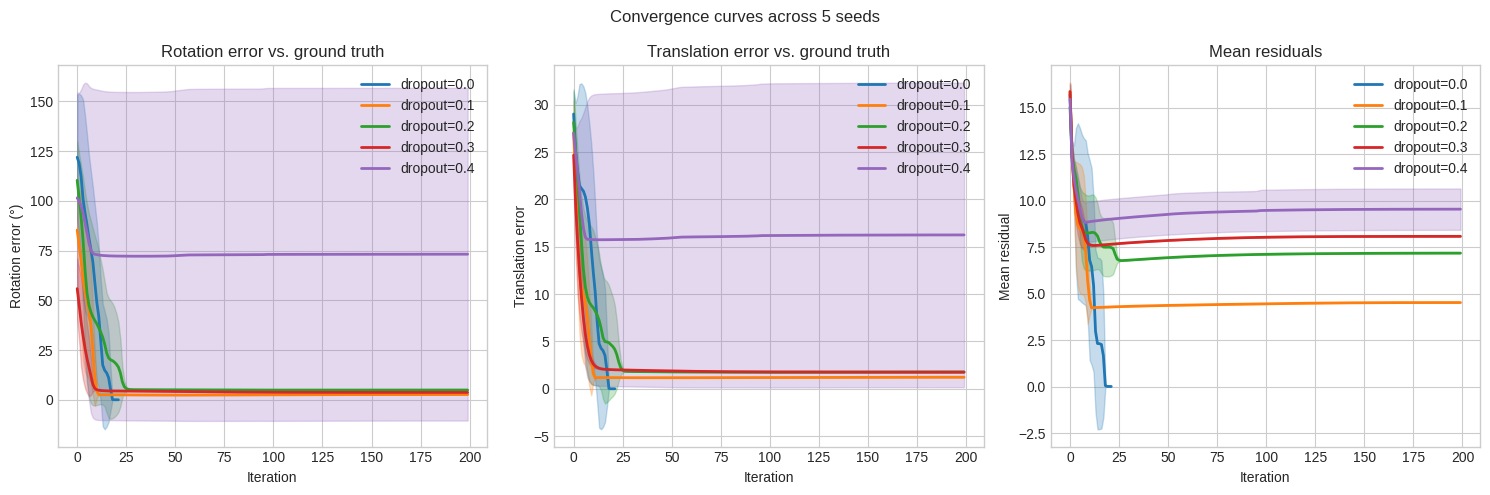

In [15]:
# Convergence curves per dropout probability (mean ± std across seeds)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ErrorMetricsVisualizer.plot_convergence_shaded(
    axes,
    results_per_method=list(best_results.values()),
    ground_truths_per_method=list(ground_truths.values()),
    method_labels=[f"dropout={dp}" for dp in DROPOUT_PROBS],
)
plt.suptitle(f"Convergence curves across {N_SEEDS} seeds")
plt.tight_layout()
plt.savefig('../results/9_rainbow_ICP_uncertain_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
for dp in DROPOUT_PROBS:
    cr = convergence_ratio(best_results[dp])
    go = convergence_to_global_opt_ratio(best_results[dp], tol=0.1)
    print(f"dropout={dp:.1f}: converged={cr*100:.1f}%  global_opt={go*100:.1f}%")

dropout=0.0: converged=100.0%  global_opt=100.0%
dropout=0.1: converged=0.0%  global_opt=0.0%
dropout=0.2: converged=0.0%  global_opt=0.0%
dropout=0.3: converged=0.0%  global_opt=0.0%
dropout=0.4: converged=0.0%  global_opt=0.0%


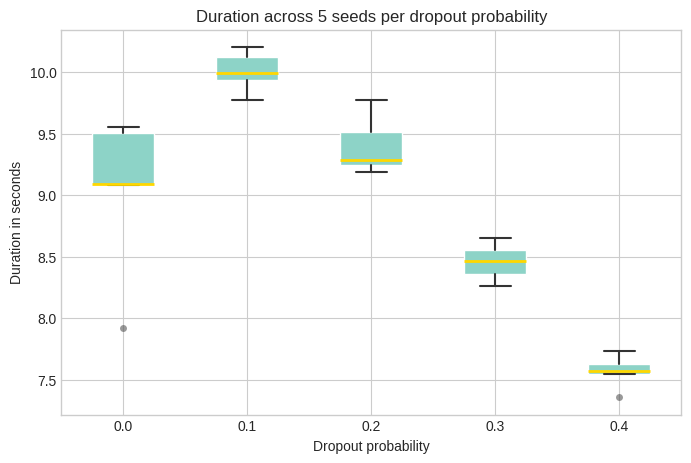

In [17]:
from visualization import _BOX_STYLE

durations = [[r.duration_s for r in results[dp]] for dp in DROPOUT_PROBS]
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(durations, tick_labels=[str(dp) for dp in DROPOUT_PROBS], **dict(_BOX_STYLE))
ax.set_xlabel("Dropout probability")
ax.set_ylabel("Duration in seconds")
ax.set_title(f"Duration across {N_SEEDS} seeds per dropout probability")
plt.savefig('../results/9_rainbow_ICP_uncertain_time.png', dpi=150, bbox_inches='tight')
plt.show()

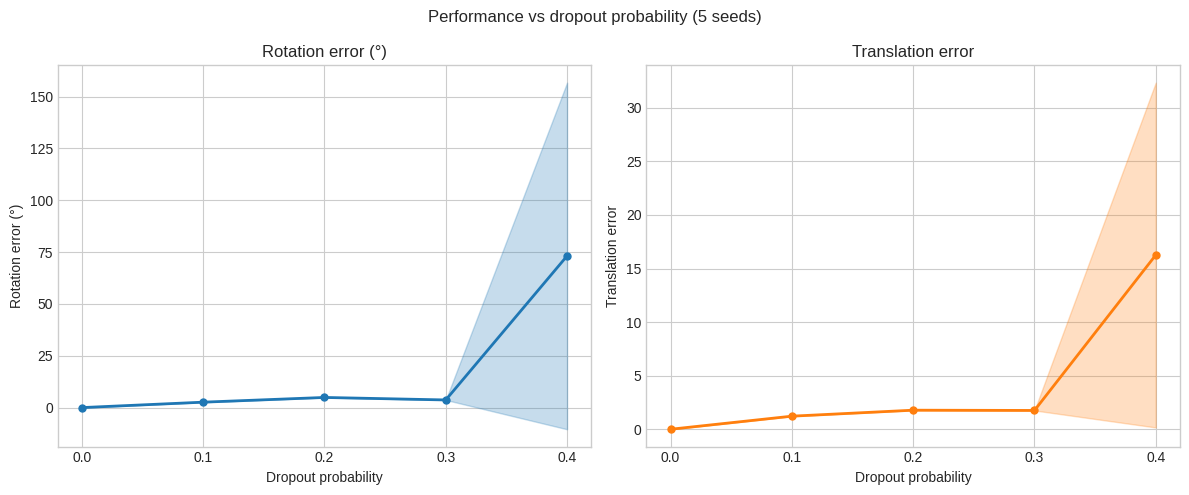

In [18]:
# Final error vs dropout probability (mean ± std across seeds)
rot_errors = np.zeros((len(DROPOUT_PROBS), N_SEEDS))
t_errors = np.zeros((len(DROPOUT_PROBS), N_SEEDS))

for i, dp in enumerate(DROPOUT_PROBS):
    for j, (result, T_gt) in enumerate(zip(best_results[dp], ground_truths[dp])):
        rot_errors[i, j] = rotation_angle_error(T_gt.R, result.transformation.R)
        t_errors[i, j] = float(np.linalg.norm(T_gt.t - result.transformation.t))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ErrorMetricsVisualizer.plot_parameter_sweep(
    axes,
    x=DROPOUT_PROBS,
    data_per_metric=[rot_errors, t_errors],
    y_labels=["Rotation error (°)", "Translation error"],
    x_label="Dropout probability",
)
plt.suptitle(f"Performance vs dropout probability ({N_SEEDS} seeds)")
plt.tight_layout()
plt.savefig('../results/9_rainbow_ICP_uncertain_results.png', dpi=150, bbox_inches='tight')
plt.show()